<a href="https://colab.research.google.com/github/you444Mo/Python-Projects/blob/main/GEN_BUS_657_Final_Project_Diabetes_Prediction_(Kaggle).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Diabetes Prediction Kaggle Competition

Background:

Dataset Description

The dataset includes patient profiles with features based on demographics, lifestyle habits, family history, and clinical measurements that are well-established indicators of diabetes risk. All data is generated using statistical distributions inspired by real-world medical research, ensuring privacy preservation while reflecting realistic health patterns.

Features:

* Column	Type	Description	Values/Range

* patient_id	Integer	Unique patient identifier

* age	Integer	Age of patient in years	18–90

* gender	String	Patient gender	'Male', 'Female', 'Other'

* ethnicity	String	Ethnic background	'White', 'Hispanic', 'Black', 'Asian','Other'

* education_level	String	Highest completed education	'No formal', 'Highschool', * 'Graduate', 'Postgraduate'

* income_level	String	Income category	'Low', 'Medium', 'High'

* employment_status	String	Employment type	'Employed', 'Unemployed', 'Retired', * 'Student'

* smoking_status	String	Smoking behavior	'Never', 'Former', 'Current'

* alcohol_consumption_per_week	Float	Drinks consumed per week	0–30

* physical_activity_minutes_per_week	Integer	Physical activity (weekly minutes)	* 0–600

* diet_score	Integer	Diet quality (higher = healthier)	0–10

* sleep_hours_per_day	Float	Average daily sleep hours	3–12

* screen_time_hours_per_day	Float	Average daily screen time hours	0–12

* family_history_diabetes	Integer	Family history of diabetes	0 = No, 1 = Yes

* hypertension_history	Integer	Hypertension history	0 = No, 1 = Yes

* cardiovascular_history	Integer	Cardiovascular history	0 = No, 1 = Yes

* bmi	Float	Body Mass Index (kg/m²)	15–45

* waist_to_hip_ratio	Float	Waist-to-hip ratio	0.7–1.2

* systolic_bp	Integer	Systolic blood pressure (mmHg)	90–180

* diastolic_bp	Integer	Diastolic blood pressure (mmHg)	60–120

* heart_rate	Integer	Resting heart rate (bpm)	50–120

* cholesterol_total	Float	Total cholesterol (mg/dL)	120–300

* hdl_cholesterol	Float	HDL cholesterol (mg/dL)	20–100

* ldl_cholesterol	Float	LDL cholesterol (mg/dL)	50–200

* triglycerides	Float	Triglycerides (mg/dL)	50–500

* glucose_fasting	Float	Fasting glucose (mg/dL)	70–250

* glucose_postprandial	Float	Post-meal glucose (mg/dL)	90–350

* insulin_level	Float	Blood insulin level (µU/mL)	2–50

* hba1c	Float	HbA1c (%)	4–14

* diabetes_risk_score	Integer	Risk score (calculated, 0–100)	0–100

* diabetes_stage	String	Stage of diabetes	'No Diabetes', 'Pre-Diabetes', 'Type * 1', 'Type 2', 'Gestational'

* diagnosed_diabetes	Integer	Target: Diabetes diagnosis	0 = No, 1 = Yes

In [ ]:
### Import Needed Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product


from statsmodels.graphics.factorplots import interaction_plot
import scipy.stats as st
from scipy.stats import pointbiserialr

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

### Traditional Modeling
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report, precision_score, roc_curve, auc, roc_auc_score

### ML Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D


### upload kaggle.json here
from google.colab import files
files.upload()

{}

In [ ]:
#pandas setting
pd.set_option('display.float_format', '{:.2f}'.format) ### Turn off scientific notation (format float)
pd.set_option('display.max_columns', None) ### always show me all columns

### Load Data From Kaggle

In [ ]:
### Kaggle setup within colab
!mkdir -p ~/.kaggle
!cp "/content/kaggle (5).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
### Download Competition data
!kaggle competitions download -c playground-series-s5e12

  0% 0.00/27.7M [00:00<?, ?B/s]
100% 27.7M/27.7M [00:00<00:00, 1.23GB/s]


In [ ]:
### Unzip Data
!unzip playground-series-s5e12.zip

Archive:  playground-series-s5e12.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
### Read Data Into DFs
Diabetes_Train = pd.read_csv("train.csv")
Diabetes_Test = pd.read_csv("test.csv")
Diabetes_Sample = pd.read_csv("sample_submission.csv")

### EDA

In [ ]:
### View Shape of Data
print(Diabetes_Train.shape)
print(Diabetes_Test.shape)

(700000, 26)
(300000, 25)


In [ ]:
### View Column Types
Diabetes_Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [ ]:
### View First View Rows of Data
Diabetes_Train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.70,6.80,6.10,33.40,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.00
1,1,50,2,73,5.70,6.50,5.80,23.80,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.00
2,2,32,3,158,8.50,7.40,9.10,24.10,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.00
3,3,54,3,77,4.60,7.00,9.20,26.60,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.00
4,4,54,1,55,5.70,6.20,5.10,28.80,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.00


In [ ]:
### See Descriptive Stats on Data
Diabetes_Train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.00,349999.50,202072.74,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.00,50.36,11.66,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.00,2.07,1.05,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.00,80.23,51.20,1.00,49.00,71.00,96.00,747.00
diet_score,700000.00,5.96,1.46,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.00,7.00,0.90,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.00,6.01,2.02,0.60,4.60,6.00,7.40,16.50
bmi,700000.00,25.87,2.86,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.00,0.86,0.04,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.00,116.29,11.01,91.00,108.00,116.00,124.00,163.00


In [ ]:
### Check for nulls
Diabetes_Train.isnull().sum()

,0
id,0
age,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0
sleep_hours_per_day,0
screen_time_hours_per_day,0
bmi,0
waist_to_hip_ratio,0
systolic_bp,0


No Nulls in Data.

In [ ]:
### Check for Dupes
Diabetes_Train[Diabetes_Train.duplicated]

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes


No Duped Records in Data.

In [ ]:
### Summarize Diabetes Diagnosis by Alchol Consumption Per Week
Alch_Summary = pd.DataFrame(
    Diabetes_Train.groupby('alcohol_consumption_per_week').agg(
        {
            'diagnosed_diabetes' : ['sum','count','mean']
            }
        ).reset_index()
  )

Alch_Summary

alcohol_consumption_per_week diagnosed_diabetes             
                                              sum   count mean
0                            1          152431.00  246311 0.62
1                            2          154567.00  246592 0.63
2                            3           85908.00  137565 0.62
3                            4           33343.00   52973 0.63
4                            5            8079.00   13322 0.61
5                            6            1676.00    2728 0.61
6                            7             266.00     447 0.60
7                            8              36.00      59 0.61
8                            9               1.00       3 0.33

Seems like regardless the number of drinks consumed per week, the diagnosis rate remains fairly constant.

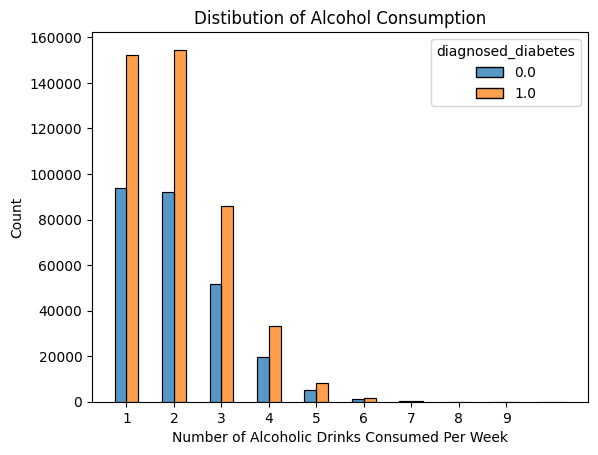

In [ ]:
### Alcohol Consumption Chart
sns.histplot(
    data = Diabetes_Train,
    x = 'alcohol_consumption_per_week',
    binrange= (np.min(Diabetes_Train['alcohol_consumption_per_week']) - 0.5, np.max(Diabetes_Train['alcohol_consumption_per_week'] + 1.5)),
    binwidth= 1,
    shrink= 0.5,
    hue = Diabetes_Train['diagnosed_diabetes'],
    multiple = 'dodge'
    )

plt.xticks([i for i in Diabetes_Train['alcohol_consumption_per_week'].unique()])
plt.xlabel("Number of Alcoholic Drinks Consumed Per Week")
plt.title("Distibution of Alcohol Consumption")
plt.show()

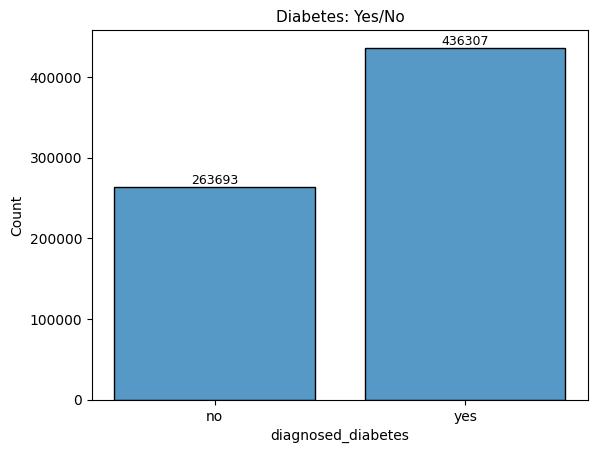

In [ ]:
### Check For balance of target variable
y = sns.histplot(
    data = Diabetes_Train,
    x = 'diagnosed_diabetes',
    binrange = (np.min(Diabetes_Train['diagnosed_diabetes']) - 0.5, np.min(Diabetes_Train['diagnosed_diabetes']) + 1.5),
    binwidth = 1,
    shrink= 0.8
)

plt.bar_label(y.containers[0], fontsize = 9)
plt.xticks([0,1], ['no','yes'])
plt.title("Diabetes: Yes/No", fontsize = 11)
plt.show()

More Skewed towards the postive class, but not heavily, will still attempt class_weight parameter from sklearn.

Correlation/outlier analysis

In [ ]:
### Drop ID Field
# Train Set
Diabetes_Train = Diabetes_Train.drop(columns = ['id'])

In [ ]:
# Test Set (Kaggle)
Diabetes_Test = Diabetes_Test.drop(columns = ['id'])

In [ ]:
Vars_Corr = list(Diabetes_Train.select_dtypes(include = ['float64','int64']).columns)

In [ ]:
Binary_Var = ['diagnosed_diabetes']

In [ ]:
### Remove Binary Vars and ID
Vars_Corr.remove('diagnosed_diabetes')
# Vars_Corr.remove('alcohol_consumption_per_week')
Vars_Corr.remove('family_history_diabetes')
Vars_Corr.remove('hypertension_history')
Vars_Corr.remove('cardiovascular_history')

In [ ]:
### Take Product of lists to pair Diabetes Diagnosis with each explanatory Variable
Combined_Vars = list(product(Binary_Var,Vars_Corr))

In [ ]:
### Compute Correlation Coefficients and P-Values
Coeff_Lst = []
Pvalue_Lst = []
for Bin,Cont in Combined_Vars:
  correlation, p_value = pointbiserialr(Diabetes_Train[Bin], Diabetes_Train[Cont])
  Coeff_Lst.append(float(correlation))
  Pvalue_Lst.append(p_value.astype('float64'))
  print(f"The Correlation Coefficient Between {Bin} and {Cont} is {correlation}, with a p-value of {p_value}.\n")

The Correlation Coefficient Between diagnosed_diabetes and age is 0.161162449350645, with a p-value of 0.0.

The Correlation Coefficient Between diagnosed_diabetes and alcohol_consumption_per_week is 0.002990931289226199, with a p-value of 0.012335663553767692.

The Correlation Coefficient Between diagnosed_diabetes and physical_activity_minutes_per_week is -0.16978868414956996, with a p-value of 0.0.

The Correlation Coefficient Between diagnosed_diabetes and diet_score is -0.05011942721024825, with a p-value of 0.0.

The Correlation Coefficient Between diagnosed_diabetes and sleep_hours_per_day is 0.0035086035502997263, with a p-value of 0.003329975897429363.

The Correlation Coefficient Between diagnosed_diabetes and screen_time_hours_per_day is 0.018212898278031932, with a p-value of 1.9411330401747047e-52.

The Correlation Coefficient Between diagnosed_diabetes and bmi is 0.10557996878711717, with a p-value of 0.0.

The Correlation Coefficient Between diagnosed_diabetes and waist_

In [ ]:
### Create Dataframe of Coefficietns
Corr_DataFrame = pd.DataFrame(data = {'Coefficients' : Coeff_Lst, 'P_values' : Pvalue_Lst},index = Vars_Corr).sort_values(by = 'Coefficients', ascending = False)

Corr_DataFrame

,Coefficients,P_values
age,0.16,0.00
systolic_bp,0.11,0.00
bmi,0.11,0.00
ldl_cholesterol,0.10,0.00
triglycerides,0.09,0.00
cholesterol_total,0.09,0.00
waist_to_hip_ratio,0.08,0.00
diastolic_bp,0.04,0.00
heart_rate,0.02,0.00
screen_time_hours_per_day,0.02,0.00


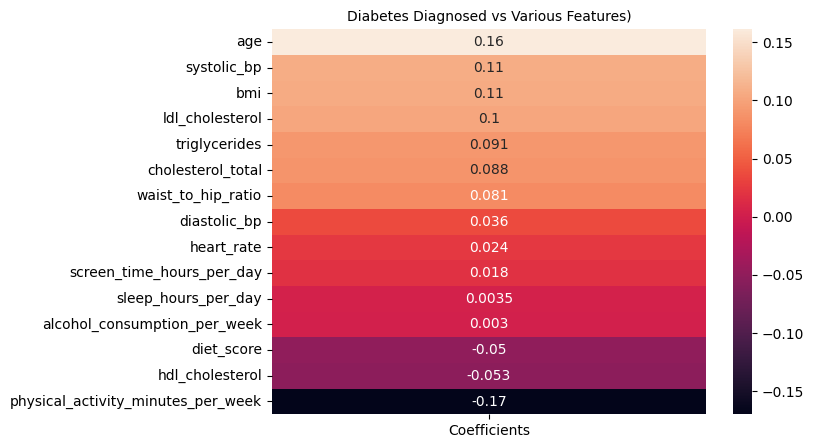

In [ ]:
### Show Heatmap
plt.figure(figsize = (7,5))
sns.heatmap(data = Corr_DataFrame[['Coefficients']], annot = True)
plt.title("Diabetes Diagnosed vs Various Features)", fontsize = 10)
plt.show()

**<u>Notes:</u>**

Age, systolic_bp, bmi, ldl_cholestrol show the most positive, statistically significant assoications with diabetes diagnosis.

Physical_activity_minutes_Per_Week, hdl_cholesterol, and diet_score show negative associations with diabetes diagnosis (makes sense).

In [ ]:
### Averages for Various Metrics (Diabetes Diagnosed vs Non-Diabetes Diagnosed)
Diabetes_Train.groupby('diagnosed_diabetes').agg(
    {
        'sleep_hours_per_day' : 'mean',
        'physical_activity_minutes_per_week' : 'mean',
        'screen_time_hours_per_day' : 'mean',
        'bmi' : 'mean',
        'waist_to_hip_ratio' : 'mean',
        'triglycerides': 'mean'
    }
)

,sleep_hours_per_day,physical_activity_minutes_per_week,screen_time_hours_per_day,bmi,waist_to_hip_ratio,triglycerides
diagnosed_diabetes,,,,,,
0.00,7.00,91.41,5.97,25.49,0.85,120.20
1.00,7.00,73.47,6.04,26.11,0.86,124.83


We notice a heavier lack of physical activity in those diagnosed with diabetes along with elivated triglycerides.

### Feature Engineering

In [ ]:
Diabetes_Train.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.70,6.80,6.10,33.40,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.00
1,50,2,73,5.70,6.50,5.80,23.80,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.00
2,32,3,158,8.50,7.40,9.10,24.10,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.00
3,54,3,77,4.60,7.00,9.20,26.60,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.00
4,54,1,55,5.70,6.20,5.10,28.80,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.00


In [ ]:
### Remove Alcohol Consumption Variable
Vars_Interaction = Vars_Corr.copy()
Vars_Interaction.remove("alcohol_consumption_per_week")

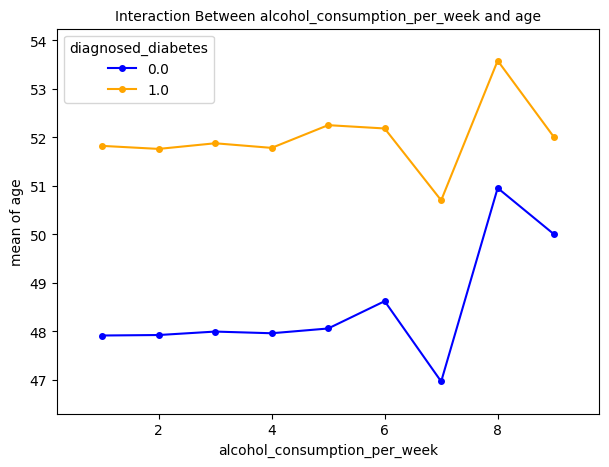

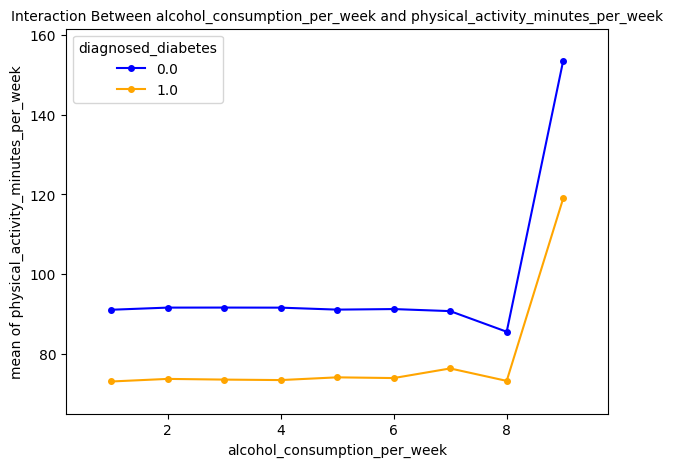

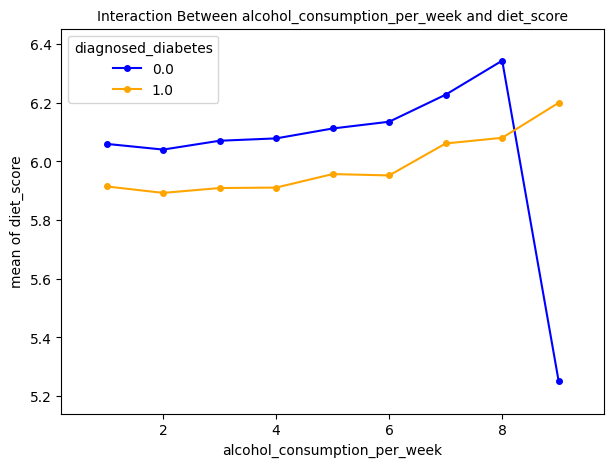

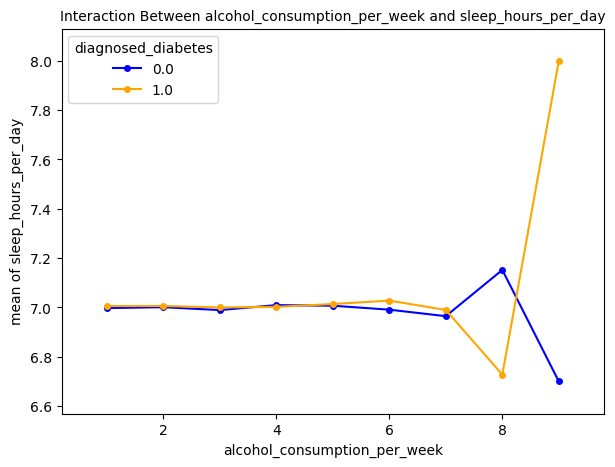

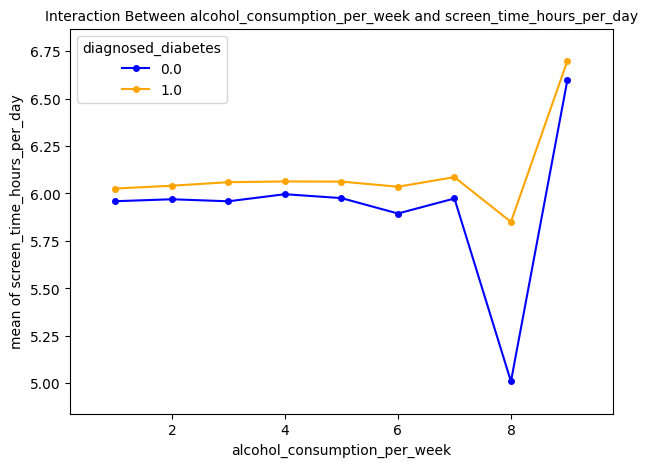

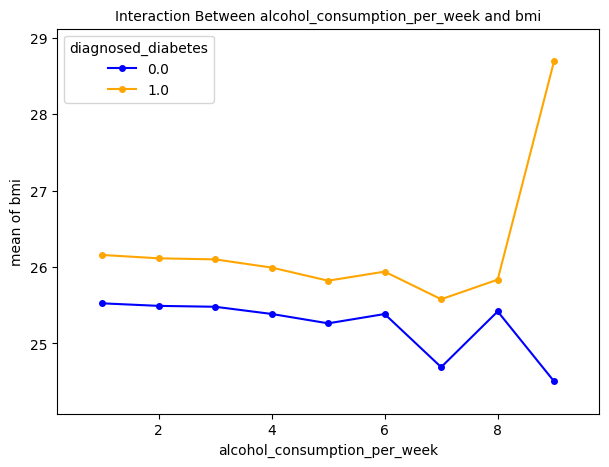

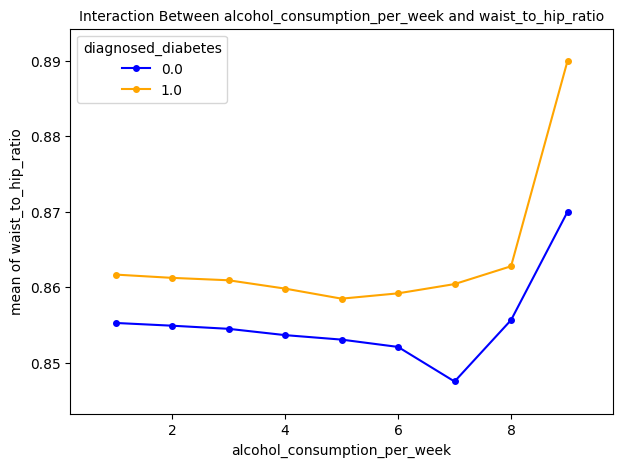

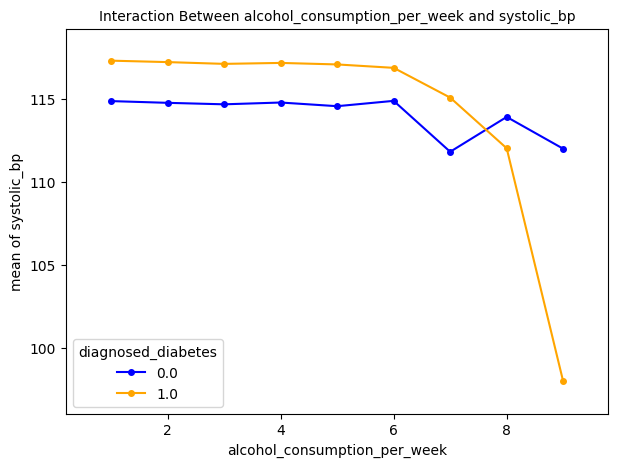

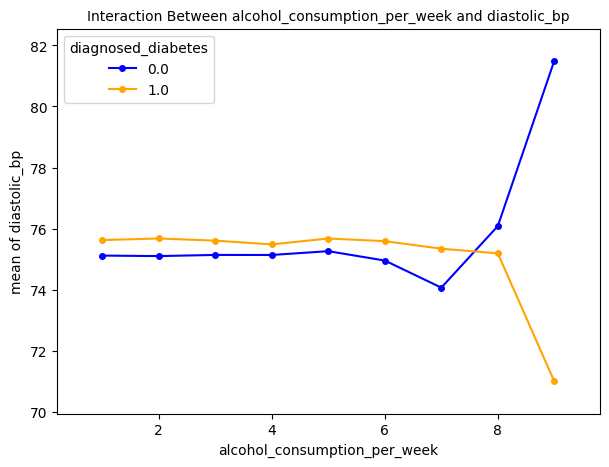

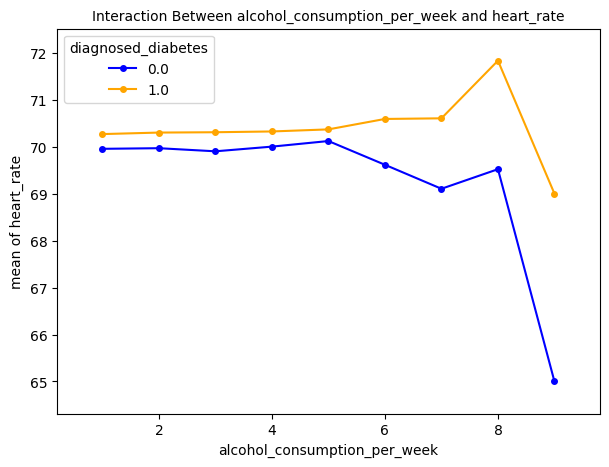

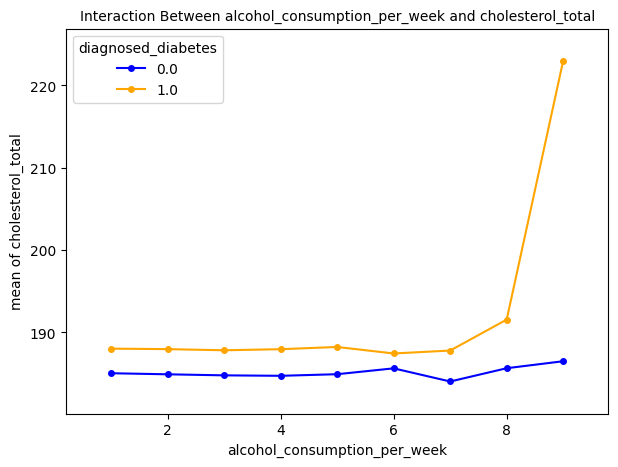

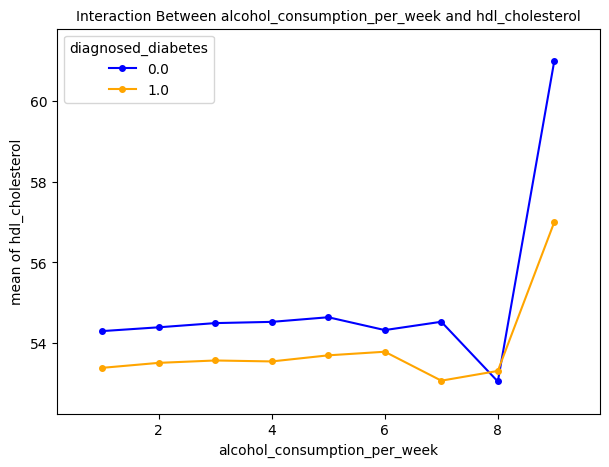

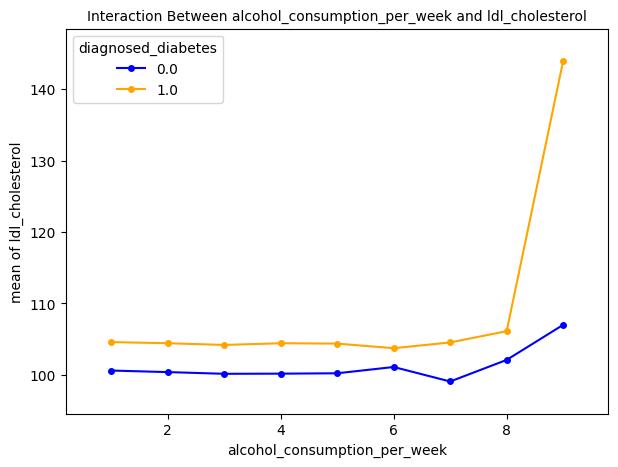

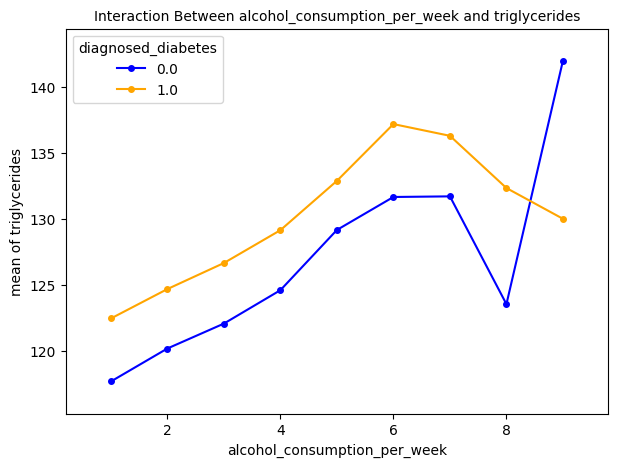

In [ ]:
### Plot interaction Terms

for x in Vars_Interaction:

  fig, ax = plt.subplots(figsize = (7,5))

  interaction_plot(
      x = Diabetes_Train['alcohol_consumption_per_week'],
      trace = Diabetes_Train['diagnosed_diabetes'],
      response = Diabetes_Train[x],
      colors = ['blue','orange'],
      ms = 8,
      ax = ax
  )

  # plt.xlabel(fontsize = 7)
  plt.title(f"Interaction Between alcohol_consumption_per_week and {x}", fontsize = 10)


  plt.tight_layout
  plt.show()
  print()

Potential Interactions:
* Alcohol_Consumption_Per Week & Triglycerides
* Alcohol_Consumption_Per Week & HDL Cholesterol
* Alcohol_Consumption_Per Week & Diastolic_BP
* Alcohol_Consumption_Per Week & Systolic_BP
* Alcohol_Consumption_Per Week & sleep_hours_per_day
* Alcohol_Consumption_Per Week & diet_score

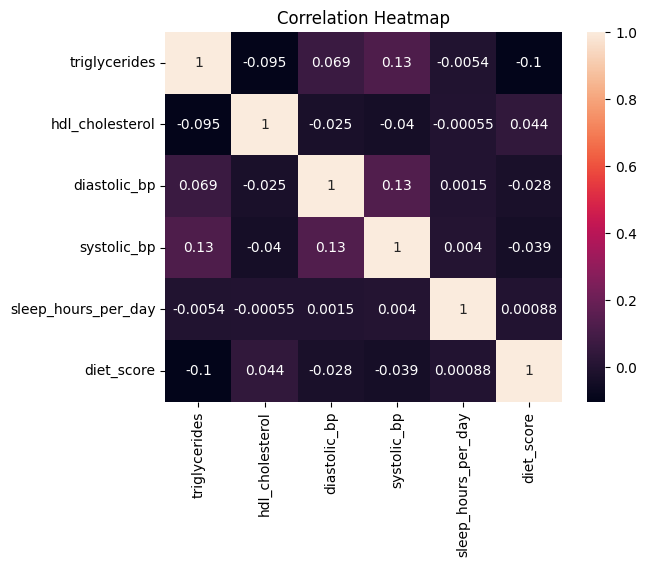

In [ ]:
### Checking Correlations between terms
lst1 = ['triglycerides','hdl_cholesterol','diastolic_bp','systolic_bp','sleep_hours_per_day','diet_score']
sns.heatmap(Diabetes_Train[lst1].corr(),annot = True)
plt.title("Correlation Heatmap")
plt.show()

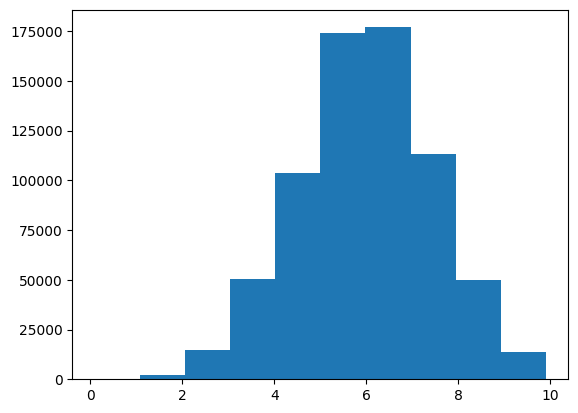

In [ ]:
### Distribution of Diet Score
plt.hist(Diabetes_Train['diet_score'])
plt.show()

#### Determinisitic Features (Prior to Split)

Due to Feature Scaling needed for certain models, we want to ensure that we only engineer features that have row-level dependencies before train test split. Scenario where we apply column-level engineering will be done post split. This is done to avoid data leakage in model training.

In [ ]:
### Training Set (Kaggle)
#### Features that can be added pre train test split (Deterministic Features)
### Blood pressure and cholesterol Ratios
Diabetes_Train['Systolic_Diastolic_Ratio'] = Diabetes_Train['systolic_bp'] / Diabetes_Train['diastolic_bp']
Diabetes_Train['Good_Vs_Bad_Chol_Ratio'] = Diabetes_Train['hdl_cholesterol'] / Diabetes_Train['ldl_cholesterol']
### Add Interaction Terms between alcohol Consumption and various features
Diabetes_Train['Alc_Consumption_DietScore'] = Diabetes_Train['alcohol_consumption_per_week'] * Diabetes_Train['diet_score']
Diabetes_Train['Alc_Consumption_SleepHours'] = Diabetes_Train['alcohol_consumption_per_week'] * Diabetes_Train['sleep_hours_per_day']
Diabetes_Train['Alc_Consumption_systolicbp'] = Diabetes_Train['alcohol_consumption_per_week'] * Diabetes_Train['systolic_bp']
Diabetes_Train['Alc_Consumption_diastolicbp'] = Diabetes_Train['alcohol_consumption_per_week'] * Diabetes_Train['diastolic_bp']
Diabetes_Train['Alc_Consumption_hdlChol'] = Diabetes_Train['alcohol_consumption_per_week'] * Diabetes_Train['hdl_cholesterol']
Diabetes_Train['Alc_Consumption_triglycerides'] = Diabetes_Train['alcohol_consumption_per_week'] * Diabetes_Train['triglycerides']

In [ ]:
### Test Set (Kaggle)
#### Features that can be added pre train test split (Deterministic Features)
### Blood pressure and cholesterol Ratios
Diabetes_Test['Systolic_Diastolic_Ratio'] = Diabetes_Test['systolic_bp'] / Diabetes_Test['diastolic_bp']
Diabetes_Test['Good_Vs_Bad_Chol_Ratio'] = Diabetes_Test['hdl_cholesterol'] / Diabetes_Test['ldl_cholesterol']
### Add Interaction Terms between alcohol Consumption and various features
Diabetes_Test['Alc_Consumption_DietScore'] = Diabetes_Test['alcohol_consumption_per_week'] * Diabetes_Test['diet_score']
Diabetes_Test['Alc_Consumption_SleepHours'] = Diabetes_Test['alcohol_consumption_per_week'] * Diabetes_Test['sleep_hours_per_day']
Diabetes_Test['Alc_Consumption_systolicbp'] = Diabetes_Test['alcohol_consumption_per_week'] * Diabetes_Test['systolic_bp']
Diabetes_Test['Alc_Consumption_diastolicbp'] = Diabetes_Test['alcohol_consumption_per_week'] * Diabetes_Test['diastolic_bp']
Diabetes_Test['Alc_Consumption_hdlChol'] = Diabetes_Test['alcohol_consumption_per_week'] * Diabetes_Test['hdl_cholesterol']
Diabetes_Test['Alc_Consumption_triglycerides'] = Diabetes_Test['alcohol_consumption_per_week'] * Diabetes_Test['triglycerides']

#### Split Kaggle Training Data into Train and Test

In [ ]:
### Target
y = Diabetes_Train['diagnosed_diabetes']
### Features
x = Diabetes_Train.drop(columns = 'diagnosed_diabetes')

In [ ]:
### Train Test Split
X_Train, X_Test, y_train, y_test, = train_test_split(x, y, test_size = 0.2, random_state = 1, stratify= y)

#### Stochastic Features

Done to avoid data leakage. Handles all feature engineering/scaling that requires the entire dataset.

In [ ]:
#### Create an Age_Squared Function

def age_squared(df,age):
  '''Input Dataframe and name of age field'''
  '''Age is first Demeaned to account for large variances'''
  df['age_squared'] = (df[age] - np.mean(df[age])) ** 2


In [ ]:
#### Create Diet Score Segment Function

def DietScore_Segments(df,score):
  '''Input Dataframe and name of diet score field'''
  '''Create Diet Score Segments'''
  df['Diet_Score_Segments'] = pd.cut(
      df[score],
      bins = 3, ### Creates 3 bins
      labels = ['Between 0 and 3.4','Between 3.4 and 6.6','Between 6.6 and 10']
  )


In [ ]:
#### Training
### Create Diet Score Segments
DietScore_Segments(X_Train,'diet_score')
DietScore_Segments(X_Test,'diet_score')

### Create Age Squared Fields
age_squared(X_Train,'age')
age_squared(X_Test,'age')

In [ ]:
#### Testing
### Create Diet Score Segments
DietScore_Segments(Diabetes_Test,'diet_score')
### Create Age Squared Fields
age_squared(Diabetes_Test,'age')

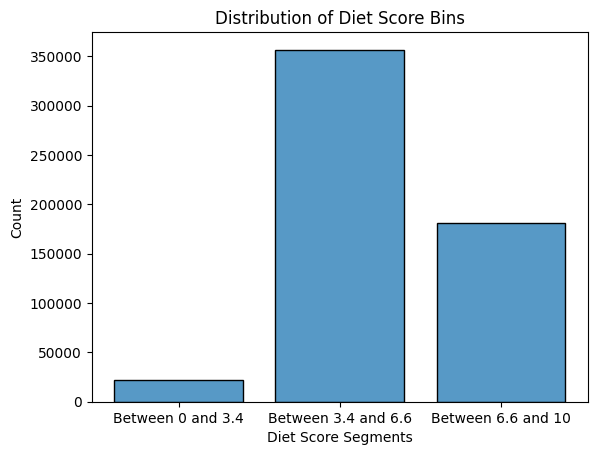

In [ ]:
### View Distribution of Diet Score Segment Bins
sns.histplot(
    data = X_Train,
    x = 'Diet_Score_Segments',
    binwidth = 1,
    shrink= 0.8
  )

plt.xlabel("Diet Score Segments")
plt.title("Distribution of Diet Score Bins")

plt.show()

#### Create Dummy Fields

In [ ]:
### Dummy Var Function
def dummies (df):
  ### Grab Categorical Fields
  ### Create Dummy Fields
  return pd.get_dummies(
    data = df.select_dtypes(include = ['object','category']),
    drop_first= True,
    dtype = int
  )


In [ ]:
### Apply to Train and Test
# Train
Diabetes_Train_Dummy = dummies(X_Train)
# Test
Diabetes_Test_Dummy = dummies(X_Test)

In [ ]:
#### Apply to Kaggle Testing Set
Diabetes_Test_Dummy_Kaggle = dummies(Diabetes_Test)

In [ ]:
### View Shape of Data
print(Diabetes_Train_Dummy.shape)
print(Diabetes_Test_Dummy.shape)
print(Diabetes_Test_Dummy_Kaggle.shape)
print(y.shape)

(560000, 20)
(140000, 20)
(300000, 20)
(700000,)


#### Scale Features

In [ ]:
### Remove Categorical Fields (Training and Testing)
# Train
X_Train_non_dummy = X_Train.select_dtypes(include = ['int64','float64'])
X_Train_non_dummy = X_Train_non_dummy.drop(columns = ['family_history_diabetes','hypertension_history','cardiovascular_history'])
# Test
X_Test_non_dummy = X_Test.select_dtypes(include = ['int64','float64'])
X_Test_non_dummy = X_Test_non_dummy.drop(columns = ['family_history_diabetes','hypertension_history','cardiovascular_history'])

In [ ]:
#### Remove Categorical Fields from Kaggle Test Set
X_Test_non_dummy_kaggle = Diabetes_Test.select_dtypes(include = ['int64','float64'])
X_Test_non_dummy_kaggle = X_Test_non_dummy_kaggle.drop(columns = ['family_history_diabetes','hypertension_history','cardiovascular_history'])

In [ ]:
### Set Scalar Object (Fit on Training Data)
Scaler = StandardScaler()
### Scale Non Dummy Fields
Diabetes_Train_Scaled = Scaler.fit_transform(X_Train_non_dummy)
### Insert Scaled data into dataframe
Diabetes_Train_Scaled_DF = pd.DataFrame(Diabetes_Train_Scaled, columns = X_Train_non_dummy.columns, index = X_Train_non_dummy.index)
### View Scaled DF
Diabetes_Train_Scaled_DF.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,Systolic_Diastolic_Ratio,Good_Vs_Bad_Chol_Ratio,Alc_Consumption_DietScore,Alc_Consumption_SleepHours,Alc_Consumption_systolicbp,Alc_Consumption_diastolicbp,Alc_Consumption_hdlChol,Alc_Consumption_triglycerides,age_squared
79826,0.74,-0.07,-0.65,0.64,-0.11,0.04,1.30,1.35,0.52,0.67,1.27,0.37,-0.46,0.90,0.64,-0.14,-0.81,0.20,-0.09,0.02,0.05,-0.19,0.14,-0.35
630933,0.05,-0.07,-0.65,1.05,-0.22,0.39,0.32,0.30,1.06,0.08,-1.18,1.09,-0.34,0.79,0.36,0.68,-0.72,0.37,-0.12,0.12,-0.05,-0.16,0.04,-0.78
62932,0.83,0.88,1.13,-0.73,-0.22,-0.80,-1.46,-1.81,0.06,0.52,-0.75,-0.65,0.02,-0.36,-0.25,-0.37,0.09,0.33,0.77,0.89,1.00,0.84,0.63,-0.25
606332,0.23,-1.02,-1.22,-0.11,0.66,0.59,-0.13,0.30,0.52,0.52,0.98,1.45,-0.70,1.06,0.97,-0.04,-0.98,-0.92,-0.91,-0.96,-0.96,-1.06,-0.74,-0.75
353196,-0.80,3.75,-0.40,0.30,-0.78,-0.60,-2.65,-2.60,-0.30,2.28,-0.17,-0.47,2.08,-1.10,-0.93,-1.62,1.96,3.65,3.05,3.51,4.83,5.26,2.30,-0.28


In [ ]:
### Apply Scaling Transformation to Testing Data (DO NOT REFIT)
Diabetes_Test_Scaled = Scaler.transform(X_Test_non_dummy)
### Insert Scaled data into dataframe
Diabetes_Test_Scaled_DF = pd.DataFrame(Diabetes_Test_Scaled, columns = X_Test_non_dummy.columns, index = X_Test_non_dummy.index)
### View Scaled DF
Diabetes_Test_Scaled_DF.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,Systolic_Diastolic_Ratio,Good_Vs_Bad_Chol_Ratio,Alc_Consumption_DietScore,Alc_Consumption_SleepHours,Alc_Consumption_systolicbp,Alc_Consumption_diastolicbp,Alc_Consumption_hdlChol,Alc_Consumption_triglycerides,age_squared
630372,-0.20,0.88,-0.57,1.46,1.22,0.14,-0.34,-0.76,-0.66,0.08,0.12,-0.94,-0.70,-0.68,1.41,-0.62,-0.09,1.67,1.28,0.69,0.89,0.54,1.46,-0.76
141198,1.69,-1.02,-1.12,-1.27,-0.22,-0.15,1.93,2.93,1.24,0.96,-0.03,1.51,-1.07,1.48,2.67,0.17,-1.26,-1.16,-1.01,-0.89,-0.92,-1.11,-0.46,1.45
367836,2.11,-1.02,-0.81,-0.11,0.11,1.53,-0.27,0.56,1.88,1.25,0.26,2.16,2.80,1.21,-1.22,0.41,0.39,-0.92,-0.97,-0.84,-0.90,-0.58,-1.11,2.73
402311,-1.75,-0.07,-0.63,-0.18,0.22,-0.99,-0.41,-0.49,-0.21,-0.94,0.98,0.25,-0.10,0.16,0.89,0.52,-0.30,-0.13,-0.01,-0.10,-0.23,-0.09,0.22,1.62
273418,-1.32,-0.07,0.95,-0.25,1.33,-0.30,-0.24,1.09,-0.57,0.81,1.13,-0.94,0.87,-1.36,0.08,-1.01,1.50,-0.16,0.25,-0.17,0.07,0.17,-0.05,0.58


In [ ]:
### Apply Scaling Tranformation to Testing Data from Kaggle (DO NOT REFIT)
Diabetes_Test_Scaled_Kaggle = Scaler.transform(X_Test_non_dummy_kaggle)
### Insert Scaled data into dataframe
Diabetes_Test_Scaled_Kaggle_DF = pd.DataFrame(Diabetes_Test_Scaled_Kaggle, columns = X_Test_non_dummy_kaggle.columns, index = X_Test_non_dummy_kaggle.index)
### View Scaled DF
Diabetes_Test_Scaled_Kaggle_DF.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,Systolic_Diastolic_Ratio,Good_Vs_Bad_Chol_Ratio,Alc_Consumption_DietScore,Alc_Consumption_SleepHours,Alc_Consumption_systolicbp,Alc_Consumption_diastolicbp,Alc_Consumption_hdlChol,Alc_Consumption_triglycerides,age_squared
0,-0.46,1.84,0.39,-1.14,-0.22,0.09,-0.13,-0.49,0.61,-0.80,-0.89,1.33,0.14,1.69,-0.49,1.06,-0.87,0.68,1.66,2.02,1.53,1.81,1.25,-0.62
1,-1.32,-1.02,0.13,-1.68,-2.66,1.48,0.95,0.56,0.34,-0.21,-1.61,-1.66,-0.82,-1.05,0.89,0.36,0.11,-1.24,-1.30,-0.97,-1.02,-1.08,-0.76,0.59
2,-0.46,-1.02,-0.38,1.12,-0.22,0.49,0.92,2.14,-0.39,-0.65,0.69,-0.82,-1.31,-0.20,2.46,0.13,-0.70,-0.67,-1.01,-1.04,-1.06,-1.15,-0.50,-0.62
3,0.40,-0.07,0.02,0.91,0.33,-0.50,0.36,1.35,-0.21,0.81,-1.32,0.97,0.63,0.69,0.20,-0.76,-0.25,0.31,0.01,-0.10,0.07,0.11,-0.01,-0.67
4,2.29,-0.07,-1.00,0.91,0.66,1.23,-1.35,-0.76,1.34,0.37,1.27,-0.59,0.63,-0.84,0.40,0.66,0.80,0.31,0.09,0.17,-0.00,0.11,0.06,3.31


In [ ]:
### View Shape of scaled DFs
print(Diabetes_Train_Scaled_DF.shape)
print(Diabetes_Test_Scaled_DF.shape)
print(Diabetes_Test_Scaled_Kaggle_DF.shape)

(560000, 24)
(140000, 24)
(300000, 24)


#### Append Orig features and Dummy Fields

In [ ]:
### Concat DataFrames (LOOK INTO WHATS HAPPENING, should not end up with more records)
# Train
Diabetes_Train_Modeling = pd.concat([Diabetes_Train_Scaled_DF,Diabetes_Train_Dummy], axis = 1)
# Test
Diabetes_Test_Modeling = pd.concat([Diabetes_Test_Scaled_DF,Diabetes_Test_Dummy], axis = 1)
# Kaggle Test Set
Diabetes_Test_Modeling_Kaggle = pd.concat([Diabetes_Test_Scaled_Kaggle_DF,Diabetes_Test_Dummy_Kaggle], axis = 1)

In [ ]:
### View Shape of Final DFs
print(Diabetes_Train_Modeling.shape)
print(Diabetes_Test_Modeling.shape)
print(Diabetes_Test_Modeling_Kaggle.shape)

(560000, 44)
(140000, 44)
(300000, 44)


### Modeling

#### Elastic Net Logistic Regression With Cross Validation:

Attempting a Logistic Regression model with various ratios of L1 and L2 penalties.

In [ ]:
### Testing different penalty values
np.logspace(-5,-1,10) ### on a log scale (base 10), start and stop points are exponents (Spacings are even in the exponents)

array([1.00000000e-05, 2.78255940e-05, 7.74263683e-05, 2.15443469e-04,
       5.99484250e-04, 1.66810054e-03, 4.64158883e-03, 1.29154967e-02,
       3.59381366e-02, 1.00000000e-01])

In [ ]:
### Penalty Tuning Parameters
alphas = np.logspace(-5,-1,10)

In [ ]:
# Create a logistic regression model with L1 penalty and cross-validation
### 5 Cross Validation folds, testing on 10 evenly spaced values for the inverse of the penalty parameter (even spaced)
ElasticNetCV_Sklearn = LogisticRegressionCV(
    class_weight = 'balanced', ### Account for Class Imbalance between Postive and Negative Classes
    fit_intercept = True,
    cv = 5, ### Number of Folds
    Cs = alphas, ### Penalty Terms to test on
    penalty='elasticnet', ### Elastic Net
    l1_ratios = [0.3,0.5,0.9], ### Ratio of Lasso to Ridge (Testing 5 different mixes)
    solver='saga',
    max_iter=10000,
    random_state = 42
    ).fit(Diabetes_Train_Modeling,y_train)  ### 10 alphas * 5 folds * 1 Different mixes of L1 Ratio = 50 fits
# Using saga lover for faster performance
# Took 31 Minutes to run with Cs = np.logspace(-5,4,25)
# Get the best model (with optimal penalty)
Best_Enet_Model = ElasticNetCV_Sklearn

In [ ]:
# Print the coefficients of the best model
count = 0
print("Coefficients of the best Elastic Net Model:")
for feature, coef in zip(Diabetes_Train_Modeling.columns, Best_Enet_Model.coef_[0]):
  count = count + 1
  print(f"{feature}: {coef}")

print(f"Total Features = {count}")

Coefficients of the best Elastic Net Model:
age: 0.2855390834322814
alcohol_consumption_per_week: 0.0
physical_activity_minutes_per_week: -0.3343677978358603
diet_score: -0.054492882777313616
sleep_hours_per_day: 0.0
screen_time_hours_per_day: 0.02248988586758146
bmi: 0.08273915453129015
waist_to_hip_ratio: 0.0
systolic_bp: 0.013727639381904298
diastolic_bp: 0.0
heart_rate: -0.021547588252572168
cholesterol_total: 0.0
hdl_cholesterol: -0.007025087820706831
ldl_cholesterol: 0.034232603441749714
triglycerides: 0.09781710365613762
Systolic_Diastolic_Ratio: 0.0038912264767816955
Good_Vs_Bad_Chol_Ratio: -0.06016595724433883
Alc_Consumption_DietScore: 0.0
Alc_Consumption_SleepHours: 0.0
Alc_Consumption_systolicbp: 0.0
Alc_Consumption_diastolicbp: 0.0
Alc_Consumption_hdlChol: 0.0
Alc_Consumption_triglycerides: 0.0
age_squared: 0.008310567791302459
gender_Male: 0.0
gender_Other: 0.0
ethnicity_Black: 0.0
ethnicity_Hispanic: 0.0
ethnicity_Other: 0.0
ethnicity_White: 0.0
education_level_Highschoo

In [ ]:
### DF of Coefficients
pd.set_option('display.float_format', '{:.10f}'.format)

Coefficient_DF = pd.DataFrame(zip(Diabetes_Train_Modeling.columns, Best_Enet_Model.coef_[0]), columns = ['Feature','Coefficient'])

In [ ]:
### Zeroed Out Coefficients
Coefficient_DF[Coefficient_DF['Coefficient'] == 0]

,Feature,Coefficient
1,alcohol_consumption_per_week,0.0000000000
4,sleep_hours_per_day,0.0000000000
7,waist_to_hip_ratio,0.0000000000
9,diastolic_bp,0.0000000000
11,cholesterol_total,0.0000000000
17,Alc_Consumption_DietScore,0.0000000000
18,Alc_Consumption_SleepHours,0.0000000000
19,Alc_Consumption_systolicbp,0.0000000000
20,Alc_Consumption_diastolicbp,0.0000000000
21,Alc_Consumption_hdlChol,0.0000000000


In [ ]:
### Non-Zero Coefficients
Coefficient_DF[Coefficient_DF['Coefficient'] != 0]

,Feature,Coefficient
0,age,0.2855390834
2,physical_activity_minutes_per_week,-0.3343677978
3,diet_score,-0.0544928828
5,screen_time_hours_per_day,0.0224898859
6,bmi,0.0827391545
8,systolic_bp,0.0137276394
10,heart_rate,-0.0215475883
12,hdl_cholesterol,-0.0070250878
13,ldl_cholesterol,0.0342326034
14,triglycerides,0.0978171037


In [ ]:
### See total coefficients that were not reduced to 0
Total_Nonzero_Coef = np.count_nonzero(Best_Enet_Model.coef_)

print(f"Total Non-Zero Coefficients {Total_Nonzero_Coef}")

Total Non-Zero Coefficients 13


In [ ]:
### Optimal Penalty Value (C)
Best_C = Best_Enet_Model.C_[0]

print(f"Optimal Penalty Term: {Best_C}")

Optimal Penalty Term: 0.00021544346900318823


In [ ]:
#### Optimal Lasso Mix
Best_l1Ratio = Best_Enet_Model.l1_ratio_

print(f"Optimal L1 Ratio: {Best_l1Ratio}")

Optimal L1 Ratio: [0.5]


In [ ]:
### Set Model
ElasticNetModel_Optimal = LogisticRegression(
    penalty = 'elasticnet',
    fit_intercept = True,
    l1_ratio = Best_l1Ratio[0],
    C = Best_C,
    class_weight = 'balanced',
    solver = 'saga',
    # max_iter = 5000,
    random_state = 42
)
### Fit Model
ElasticNetModel_Optimal_Fitted = ElasticNetModel_Optimal.fit(Diabetes_Train_Modeling,y_train)

##### Model Evaluation:

In [ ]:
# Predict probabilities using the best LASSO model
p_x_ElasticNet_optimal = ElasticNetModel_Optimal_Fitted.predict_proba(Diabetes_Test_Modeling)[:, 1]

# Classify predictions based on a 0.5 cutoff
y_hat_ElesticNet_optimal = (p_x_ElasticNet_optimal > 0.5)

In [ ]:
# Create confusion matrix
conf_mat_ElasNet_Optimal = pd.crosstab(y_test, y_hat_ElesticNet_optimal, rownames=['Actual Diagnosis'], colnames=['Predicted Diagnosis'])

# Add row and column sums
conf_mat_ElasNet_Optimal.loc['Column_Total'] = conf_mat_ElasNet_Optimal.sum(numeric_only=True, axis=0)
conf_mat_ElasNet_Optimal.loc[:, 'Row_Total'] = conf_mat_ElasNet_Optimal.sum(numeric_only=True, axis=1)

print("\nConfusion Matrix (Elastic Net Optimal):")
print(conf_mat_ElasNet_Optimal)


Confusion Matrix (Elastic Net Optimal):
Predicted Diagnosis  False   True  Row_Total
Actual Diagnosis                            
0.0000000000         30753  21986      52739
1.0000000000         32210  55051      87261
 Column_Total        62963  77037     140000


In [ ]:
### Confusion Matrix Key Metrics at 0.5 cuttoff
FN = 32210
FP = 21986
TN = 30753
TP = 55051
Tot_Positives = FN + TP
Tot_Negatives = FP + TN
N_Plus_P = Tot_Positives + Tot_Negatives

MCR = (FP + FN)/N_Plus_P
TPR = TP/Tot_Positives  ### Out of all positive cases (FN and TP), what % where accurately labeled positive
TNR = TN/Tot_Negatives
precision = TP/(TP + FP) ### Out of all cases labeled Positive (TP and FP) what % were accurately labeled positive
Accuracy = (TP + TN) / (FN + FP + TN + TP)

print(f"The Misclassified Rate is: {MCR * 100:.2f}%")
print(f"The True Positive Rate (Sensitivity or Recall) is: {TPR * 100:.2f}%")
print(f"The True Negative Rate (Specifity) is: {TNR * 100:.2f}%")
print(f"The Precision is: {precision * 100:.2f}%")
print(f"The Accuracy is: {Accuracy * 100:.2f}%")

The Misclassified Rate is: 38.71%
The True Positive Rate (Sensitivity or Recall) is: 63.09%
The True Negative Rate (Specifity) is: 58.31%
The Precision is: 71.46%
The Accuracy is: 61.29%


Decent Precision of 71.46%. A 61.29% accuracy metric is okay. TPR of 63% and TNR of 58% are all also just okay. This dataset may benefit from an ensemble learner in order to more accuratly distinguish between those with diabetes and those without.

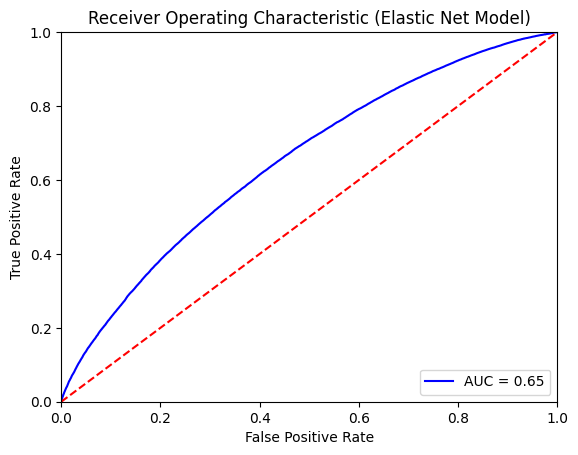

In [ ]:
# Generate ROC curve
fpr_els, tpr_els, threshold_els = roc_curve(y_test, p_x_ElasticNet_optimal)
roc_auc_els = auc(fpr_els, tpr_els)

plt.title('Receiver Operating Characteristic (Elastic Net Model)')
plt.plot(fpr_els, tpr_els, 'b', label='AUC = %0.2f' % roc_auc_els)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

With an AUC of 0.65, the model is decent, but not great at distinguishing between the positive class (diabetes = 1) and negative class (diabetes = 0). We will try some more modern machine learning approaches to see if there is improvement.

#### Gradient Boosted Tree:

Will will first try to fit a HistGradientBoost Model, as this variation of the gradient boost algorithm works more efficiently on larger datasets.

In [ ]:
### Fit HistGradientBoost Ensemble
Diabetes_GB = HistGradientBoostingClassifier(
    max_iter=200, ### 200 trees
    max_depth=10, ### Tree depth of 10
    learning_rate=0.05, ### Learning Rate of 0.05 (contribution of each tree to the overall prediction)
    class_weight = 'balanced', ### Accounting for class imbalance
    random_state=42
)

Diabetes_GB_Fitted = Diabetes_GB.fit(Diabetes_Train_Modeling, y_train)

##### Evaluation:

In [ ]:
#### Predictions
Pred_Diab_GB = Diabetes_GB_Fitted.predict_proba(Diabetes_Test_Modeling)[:,1]

In [ ]:
# Classify predictions based on a 0.5 cutoff
Pred_Diab_GB_cuttoff = (Pred_Diab_GB > 0.5)

In [ ]:
# Create confusion matrix
conf_mat_Boost = pd.crosstab(y_test, Pred_Diab_GB_cuttoff, rownames=['Actual Diagnosis'], colnames=['Predicted Diagnosis'])

# Add row and column sums
conf_mat_Boost.loc['Column_Total'] = conf_mat_Boost.sum(numeric_only=True, axis=0)
conf_mat_Boost.loc[:, 'Row_Total'] = conf_mat_Boost.sum(numeric_only=True, axis=1)

print("\nConfusion Matrix (Gradient Boost Ensemble):")
print(conf_mat_Boost)


Confusion Matrix (Gradient Boost Ensemble):
Predicted Diagnosis  False   True  Row_Total
Actual Diagnosis                            
0.00                 33203  19536      52739
1.00                 31822  55439      87261
 Column_Total        65025  74975     140000


In [ ]:
### Confusion Matrix Key Metrics at 0.5 cuttoff
FN = 31822
FP = 19536
TN = 33203
TP = 55439
Tot_Positives = FN + TP
Tot_Negatives = FP + TN
N_Plus_P = Tot_Positives + Tot_Negatives

MCR = (FP + FN)/N_Plus_P
TPR = TP/Tot_Positives  ### Out of all positive cases (FN and TP), what % where accurately labeled positive
TNR = TN/Tot_Negatives
precision = TP/(TP + FP) ### Out of all cases labeled Positive (TP and FP) what % were accurately labeled positive
Accuracy = (TP + TN) / (FN + FP + TN + TP)

print(f"The Misclassified Rate is: {MCR * 100:.2f}%")
print(f"The True Positive Rate (Sensitivity or Recall) is: {TPR * 100:.2f}%")
print(f"The True Negative Rate (Specifity) is: {TNR * 100:.2f}%")
print(f"The Precision is: {precision * 100:.2f}%")
print(f"The Accuracy is: {Accuracy * 100:.2f}%")

The Misclassified Rate is: 36.68%
The True Positive Rate (Sensitivity or Recall) is: 63.53%
The True Negative Rate (Specifity) is: 62.96%
The Precision is: 73.94%
The Accuracy is: 63.32%


We see improvement across the board in terms of the confusion matrix KPIs vs the Elastic Net Logistic Model. About a 2% increase in accuracy and precision along with a 2% decrease in the misclassification rate.

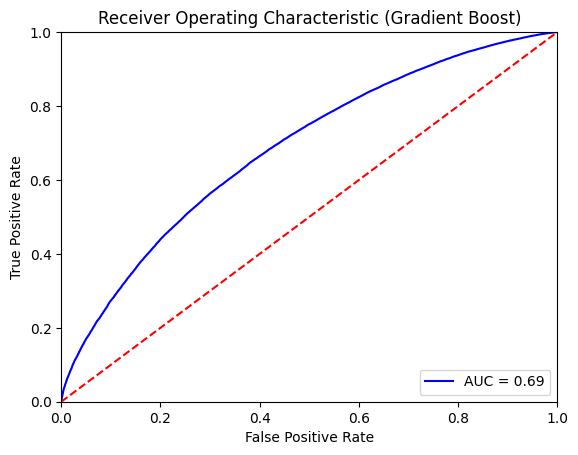

In [ ]:
### View ROC Curve
fpr_GB, tpr_GB, threshold_GB = roc_curve(y_test, Pred_Diab_GB)
roc_auc_GB = auc(fpr_GB, tpr_GB)

plt.title('Receiver Operating Characteristic (Gradient Boost)')
plt.plot(fpr_GB, tpr_GB, 'b', label='AUC = %0.2f' % roc_auc_GB)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Marked improvement in the AUC (0.69), indicating that this model is better at distinguishing between the classes.

Overall, the gradient boosted ensemble showed a fair amount of improvement over the elastic net logistic model, and this was without tuning. We next try a tuned varient of the this model to see if there is improvement.

#### Gradient Boosted Tree (Tuned):

In [ ]:
### Set total estimators, learning rate penalty, and tree_depth options
n_estimators_grid = [100,200,500,1000]
learning_rate_grid = [0.001,0.01,0.05,0.1]
tree_depth_grid = [2,5,8,10]

In [ ]:
### Iterate over grid of total estimator/learning rate combos/tree_depth combos
best_auc = 0
best_params = {}

for n_estimators in n_estimators_grid:
  for learning_rate in learning_rate_grid:
    for tree_depth in tree_depth_grid:
      Diabetes_GB_Optimal = HistGradientBoostingClassifier(      # Train the GradientBoostingClassifier with the current parameters
        max_iter = n_estimators, ### 200 trees
        max_depth = tree_depth, ### Tree depth of 10
        learning_rate = learning_rate, ### Learning Rate of 0.05 (contribution of each tree to the overall prediction)
        class_weight = 'balanced', ### Accounting for class imbalance
        random_state=42
      )
      Diabetes_GB_Optimal.fit(Diabetes_Train_Modeling, y_train)

      # Predict probabilities for the test set
      Diabetes_boost_optimal_pred = Diabetes_GB_Optimal.predict_proba(Diabetes_Test_Modeling)[:, 1]

      # Calculate the AUC score
      auc_score = roc_auc_score(y_test, Diabetes_boost_optimal_pred)

      # Update the best AUC and parameters if the current AUC is better
      if auc_score > best_auc:
          best_auc = auc_score
          best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate, 'tree_depth' : tree_depth}

print("Best AUC:", best_auc)
print("Best parameters:", best_params)

Best AUC: 0.6897160121527451
Best parameters: {'n_estimators': 1000, 'learning_rate': 0.05, 'tree_depth': 5}


<u>Notes:</u>

Optimal Parameters

* n_estimators: 1000
* learning_rate: 0.05
* tree_depth: 5

In [ ]:
### Fit Tuned Model
Diabetes_GB_Tuned = HistGradientBoostingClassifier(
    max_iter=1000, ### 1000 trees
    max_depth=5, ### Tree depth of 5
    learning_rate=0.05, ### Learning Rate of 0.05 (contribution of each tree to the overall prediction)
    class_weight = 'balanced', ### Accounting for class imbalance
    random_state=42
)

Diabetes_GB_Tuned_fitted = Diabetes_GB_Tuned.fit(Diabetes_Train_Modeling, y_train)

##### Evaluation:

In [ ]:
#### Predictions
Pred_Diabetes_GB_Tuned = Diabetes_GB_Tuned_fitted.predict_proba(Diabetes_Test_Modeling)[:,1]

In [ ]:
# Classify predictions based on a 0.5 cutoff
Pred_Diab_GB_Tuned_cuttoff = (Pred_Diabetes_GB_Tuned > 0.5)

In [ ]:
# Create confusion matrix (Start Here!!!!)
conf_mat_Boost_tuned = pd.crosstab(y_test, Pred_Diab_GB_Tuned_cuttoff, rownames=['Actual Diagnosis'], colnames=['Predicted Diagnosis'])

# Add row and column sums
conf_mat_Boost_tuned.loc['Column_Total'] = conf_mat_Boost_tuned.sum(numeric_only=True, axis=0)
conf_mat_Boost_tuned.loc[:, 'Row_Total'] = conf_mat_Boost_tuned.sum(numeric_only=True, axis=1)

print("\nConfusion Matrix (Gradient Boost - Tuned):")
print(conf_mat_Boost_tuned)


Confusion Matrix (Gradient Boost - Tuned):
Predicted Diagnosis  False   True  Row_Total
Actual Diagnosis                            
0.00                 33299  19440      52739
1.00                 31383  55878      87261
 Column_Total        64682  75318     140000


In [ ]:
### Confusion Matrix Key Metrics at 0.5 cuttoff
FN = 31383
FP = 19440
TN = 33299
TP = 55878
Tot_Positives = FN + TP
Tot_Negatives = FP + TN
N_Plus_P = Tot_Positives + Tot_Negatives

MCR = (FP + FN)/N_Plus_P
TPR = TP/Tot_Positives  ### Out of all positive cases (FN and TP), what % where accurately labeled positive
TNR = TN/Tot_Negatives
precision = TP/(TP + FP) ### Out of all cases labeled Positive (TP and FP) what % were accurately labeled positive
Accuracy = (TP + TN) / (FN + FP + TN + TP)

print(f"The Misclassified Rate is: {MCR * 100:.2f}%")
print(f"The True Positive Rate (Sensitivity or Recall) is: {TPR * 100:.2f}%")
print(f"The True Negative Rate (Specifity) is: {TNR * 100:.2f}%")
print(f"The Precision is: {precision * 100:.2f}%")
print(f"The Accuracy is: {Accuracy * 100:.2f}%")

The Misclassified Rate is: 36.30%
The True Positive Rate (Sensitivity or Recall) is: 64.04%
The True Negative Rate (Specifity) is: 63.14%
The Precision is: 74.19%
The Accuracy is: 63.70%


We do see improvement in the tuned gradient boost model vs that of the base model. Very small gains in Precision and Accuracy (< 1%) and about a 0.38% decrease in the misclassification rate.

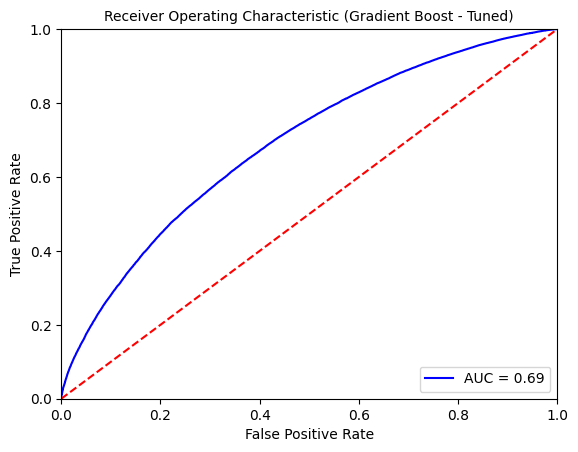

In [ ]:
### View ROC Curve
fpr_GB_tuned, tpr_GB_tuned, threshold_GB_tuned = roc_curve(y_test,Pred_Diabetes_GB_Tuned )
roc_auc_GB = auc(fpr_GB_tuned, tpr_GB_tuned)

plt.title('Receiver Operating Characteristic (Gradient Boost - Tuned)', fontsize = 10)
plt.plot(fpr_GB_tuned, tpr_GB_tuned, 'b', label='AUC = %0.2f' % roc_auc_GB)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

We see the same AUC vs that of the un-tuned model.

#### Neural Net:

In [ ]:
Diabetes_Train_Modeling.shape

(560000, 44)

In [ ]:
### Handle Class imbalance
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

print(class_weight)

{0: np.float64(1.3273035827715995), 1: np.float64(0.8021865312881397)}


Multilayer Perceptron:

4 layers, number of neurons decreasing by 1/2 for each layer (starting with 44)

In [ ]:
### Set up Neural Net Input Parameters
inputs = keras.Input(shape=(44,)) ### Total inputs
x = layers.Dense(44, activation="relu", name="dense_1")(inputs) ### Using Relu
x = layers.Dropout(0.2, name = 'dropout_1')(x) ### Regularization Technique: Randomly turns off neurons during training so model doesn't rely too heavily on certain ones (done on 20% of neurons)

x = layers.Dense(32, activation="relu", name="dense_2")(x)
x = layers.Dropout(0.2, name = 'dropout_2')(x)

x = layers.Dense(16, activation="relu", name="dense_3")(x)
x = layers.Dropout(0.2, name = 'dropout_3')(x)

x = layers.Dense(8, activation = "relu", name = "dense_4")(x)
x = layers.Dropout(0.2, name = 'dropout_4')(x)

outputs = layers.Dense(1, activation="sigmoid", name="predictions")(x) ### Using sigmoid function to get a value between 0 and 1
diabetes_nnet = keras.Model(inputs=inputs, outputs=outputs)
diabetes_nnet.compile(
  optimizer=keras.optimizers.Adam(learning_rate=0.001),
  # Loss function to minimize
  loss='binary_crossentropy',
  # List of metrics to monitor
  metrics=['accuracy'],
)

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', ### Loss function to be monitored
    patience= 10, ### Number of epochs with no improvement after which training will be stopped. Defaults to 0.
    restore_best_weights = True ### Keeps best model, rather than just grabbing the one at the stoppage point.
    )

In [ ]:
### Show NNET attributes
diabetes_nnet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,093 (15.99 KB)

 Trainable params: 4,093 (15.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Fit Neural net (using 50 epochs)
diabetes_nnet_fit = diabetes_nnet.fit(
  Diabetes_Train_Modeling,
  y_train,
  batch_size= 256, ### how many samples to use in gradient descent update
  epochs = 50, ### Each epoch is one full cycle through the whole dataset (trying 50)
  validation_split = 0.2, ### view validation loss (to examine how well model generalizes)
  callbacks=[early_stopping], ### Kill algorithm after 10 straight decreases in the loss function (Retain the best one)
  class_weight = class_weight ### accounts for class imbalance
)

Epoch 1/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5940 - loss: 0.6692 - val_accuracy: 0.6170 - val_loss: 0.6483
Epoch 2/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6044 - loss: 0.6617 - val_accuracy: 0.6093 - val_loss: 0.6511
Epoch 3/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.6062 - loss: 0.6605 - val_accuracy: 0.6130 - val_loss: 0.6546
Epoch 4/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6079 - loss: 0.6599 - val_accuracy: 0.6144 - val_loss: 0.6512
Epoch 5/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6095 - loss: 0.6594 - val_accuracy: 0.6171 - val_loss: 0.6538
Epoch 6/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6087 - loss: 0.6592 - val_accuracy: 0.6037 - val_loss: 0.6578
Epoch 7/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6083 - loss: 0.6592 - val_accuracy: 0.6172 - val_loss: 0.6549
Epoch 8/50
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6102 - loss: 0.6587

##### Evaluation:

In [ ]:
### Get Predictions
diabetes_nnet_predictions = diabetes_nnet.predict(Diabetes_Test_Modeling)
diabetes_nn_cuttoff = diabetes_nnet_predictions > 0.5

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


In [ ]:
### Check Confusion Matrix at cuttoff threshold: 50%
conf_matrix_nnet = confusion_matrix(y_test, (diabetes_nn_cuttoff.T[0]) )

# Create a DataFrame for better visualization
conf_matrix_nnet_df = pd.DataFrame(conf_matrix_nnet,
                             index=['Actual No', 'Actual Yes'],
                             columns=['Predicted No', 'Predicted Yes'])
conf_matrix_nnet_df

,Predicted No,Predicted Yes
Actual No,29978,22761
Actual Yes,30931,56330


In [ ]:
### Evaluation Metrics model confusion matrix
FN = 30931
FP = 22761
TN = 29978
TP = 56330
Tot_Positives = FN + TP
Tot_Negatives = FP + TN
N_Plus_P = Tot_Positives + Tot_Negatives

MCR = (FP + FN)/N_Plus_P
TPR = TP/Tot_Positives  ### Out of all positive cases (FN and TP), what % where accurately labeled positive
TNR = TN/Tot_Negatives
precision = TP/(TP + FP) ### Out of all cases labeled Positive (TP and FP) what % were accurately labeled positive
Accuracy = (TP + TN) / (FN + FP + TN + TP)

print(f"The Misclassified Rate is: {MCR * 100:.2f}%")
print(f"The True Positive Rate (Sensitivity or Recall) is: {TPR * 100:.2f}%")
print(f"The True Negative Rate (Specifity) is: {TNR * 100:.2f}%")
print(f"The Precision is: {precision * 100:.2f}%")
print(f"The Accuracy is: {Accuracy * 100:.2f}%")

The Misclassified Rate is: 38.35%
The True Positive Rate (Sensitivity or Recall) is: 64.55%
The True Negative Rate (Specifity) is: 56.84%
The Precision is: 71.22%
The Accuracy is: 61.65%


We see that a more complex neural net has very similar performance to that of the other models for this particular data set. The performance is actually very close to that of the elastic net model.

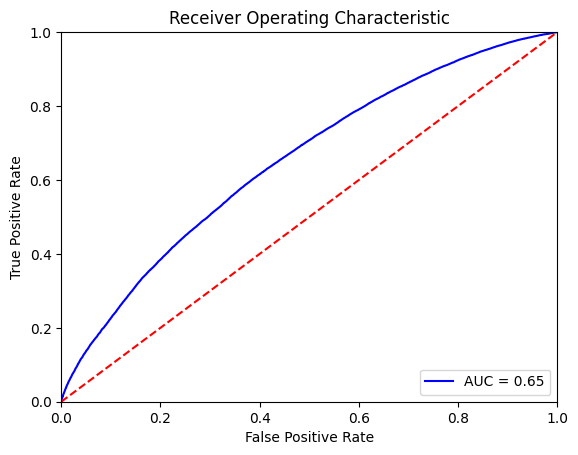

In [ ]:
### Show ROC Curve
fpr, tpr, threshold = roc_curve(y_test, diabetes_nnet_predictions)
roc_auc = auc(fpr, tpr)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

We see that the model's ability to distinguish between the positive and negative classes is no better than the much simpler Elastic Net regression.

Generally, the tuned Gradient Boosted Tree was the best fit on the data.

### Prep For Kaggle Submission

In [ ]:
### Test Feature Matrix
X_Test_Kaggle = Diabetes_Test_Modeling_Kaggle
X_Test_Kaggle.shape

(300000, 44)

In [ ]:
### Predict Probabilities Using optimal Elastic Net Model
p_x_TunedGradientBoost_KaggleTest = Diabetes_GB_Tuned_fitted.predict_proba(X_Test_Kaggle)[:, 1]

In [ ]:
### Grab IDs from Test DF
Diabetes_Test_IDs = pd.read_csv("test.csv")['id']

In [ ]:
#### Convert Probability Array to Dataframe
Prob_DF = pd.DataFrame(p_x_TunedGradientBoost_KaggleTest).rename(columns = {0 : 'diagnosed_diabetes'})
### Concatenate Ids to Probabilites
Final_Predictions = pd.concat([Diabetes_Test_IDs,Prob_DF], axis = 1)

In [ ]:
### Show Predictions DF
Final_Predictions.head(10)

,id,diagnosed_diabetes
0,700000,0.44
1,700001,0.59
2,700002,0.72
3,700003,0.32
4,700004,0.89
5,700005,0.59
6,700006,0.66
7,700007,0.69
8,700008,0.49
9,700009,0.73


In [ ]:
# File Path
Final_Predictions.to_csv("Kaggle_Diabetes_Submission.csv", index = False)